In [1]:
import re
import os
import sys
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from nltk import pos_tag
from spacy.lang.en.stop_words import STOP_WORDS as SPACY_STOP_WORDS

import gensim
from gensim import corpora
from gensim.models import CoherenceModel

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

try:
    import torch
except Exception:
    torch = None



def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)

    for p in [start.resolve()] + list(start.resolve().parents):
        if (p / "csvs").exists() and (p / "markdown").exists():
            return p

    return start.resolve()


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


try:
    import scripts.text_mining_utils as tmu
except ImportError:
    tmu = None
    print("Warning: scripts.text_mining_utils not found. Continuing without it.")



CSVS_CHUNKED = PROJECT_ROOT / "csvs" / "chunked"
CHUNKS_ALL = CSVS_CHUNKED / "chunks_all.csv"

PIPELINE_DIR = (
    PROJECT_ROOT
    / "progress"
    / "topic_modelling"
    / "nmf"
    / "sentiment"
)

OUT_DIR = PIPELINE_DIR / "output"

OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_DIR = OUT_DIR.parent / "img"
IMG_DIR.mkdir(parents=True, exist_ok=True)


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 160)



NLTK_DATA_DIR = PROJECT_ROOT / "data" / "auto"
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)

if str(NLTK_DATA_DIR) not in nltk.data.path:
    nltk.data.path.append(str(NLTK_DATA_DIR))

nltk_packages = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]

for package in nltk_packages:
    try:
        nltk.download(package, download_dir=str(NLTK_DATA_DIR), quiet=True)
    except Exception as e:
        print(f"Warning: NLTK package not available: {package} ({e})")


print("Project root:", PROJECT_ROOT)
print("Input chunks file:", CHUNKS_ALL)
print("Pipeline folder:", PIPELINE_DIR)
print("Output folder:", OUT_DIR)
print("Image folder:", IMG_DIR)
print("Utility module:", None if tmu is None else tmu.__name__)
print("Topic backbone: TF-IDF unigram+bigram + NMF")
print("SLM usage: topic-level selection and topic-level labels only")


Project root: /home/nsirim/Github/mscdsa/msc
Input chunks file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Pipeline folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment
Output folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output
Image folder: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/img
Utility module: scripts.text_mining_utils
Topic backbone: TF-IDF unigram+bigram + NMF
SLM usage: topic-level selection and topic-level labels only


In [2]:
# ==========================================
# Step 1: Load sentiment chunks
# ==========================================

CORPUS_FILTER = "sentiment"

required_columns = {
    "doc_id",
    "corpus",
    "source_type",
    "country",
    "heading_context",
    "chunk_text",
}


# ==========================================
# Helper functions for text construction
# Same text-construction logic used in the companion corpus pipeline
# ==========================================

def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()


def normalise_heading_text(heading):
    heading = safe_text(heading)
    heading = re.sub(r"\s+", " ", heading)
    heading = re.sub(r"^\d+(\.\d+)*\s+", "", heading)
    return heading.strip()


def build_original_heading_context_chunk_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if heading and chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    return f"{heading} {chunk_text}".strip()


def build_nmf_source_text(row):
    heading = normalise_heading_text(row["heading_context"])
    chunk_text = safe_text(row["chunk_text"])

    if not heading:
        return chunk_text

    if chunk_text.lower().startswith(heading.lower()):
        return chunk_text

    heading_word_count = len(heading.split())

    if heading_word_count <= 12:
        return f"{heading}. {chunk_text}"

    return chunk_text


# ==========================================
# Optional artifact removal
# Same artifact-removal style used in the companion corpus pipeline
# ==========================================

def remove_document_artifact_chunks(dataframe):
    artifact_heading_pattern = re.compile(
        r"^(contents|table of contents|acknowledgements?|acknowledgments?|"
        r"acronyms?|abbreviations?|illustrations?|bibliography|references|"
        r"web sources|about the author|about the authors|authors?|cover|"
        r"copyright|appendix|annex|figures?|tables?|foreword|preface)$",
        re.IGNORECASE,
    )

    artifact_text_pattern = re.compile(
        r"(table of contents|copyright|all rights reserved|isbn|bibliography|"
        r"references|web sources|cover photo|printed in|printed by|"
        r"designed and printed|directorate of communications|creative commons|"
        r"open access repository|legal status of any country|frontiers or boundaries|"
        r"does not imply the expression|shutterstock|doi\.org|creativecommons|"
        r"attribution-sharealike)",
        re.IGNORECASE,
    )

    heading_mask = (
        dataframe["heading_context"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.match(artifact_heading_pattern)
    )

    text_mask = (
        dataframe["chunk_text"]
        .fillna("")
        .astype(str)
        .str[:900]
        .str.contains(artifact_text_pattern, regex=True, na=False)
    )

    artifact_mask = heading_mask | text_mask

    return dataframe.loc[~artifact_mask].copy(), int(artifact_mask.sum())


# ==========================================
# Step 2: Load and prepare sentiment dataframe
# ==========================================

try:
    # Use the project CSV path first; fall back to a local chunks_all*.csv if needed.
    input_chunks_file = CHUNKS_ALL

    if not input_chunks_file.exists():
        # Fallback is useful when the notebook is run outside the project folder.
        fallback_dirs = [PROJECT_ROOT, Path.cwd(), Path("/mnt/data")]
        local_candidates = []

        for folder in fallback_dirs:
            if folder.exists():
                local_candidates.extend(sorted(folder.glob("chunks_all*.csv")))

        if local_candidates:
            input_chunks_file = local_candidates[0]

    print("Input file:", input_chunks_file)

    df = pd.read_csv(input_chunks_file, encoding="utf-8-sig")

    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

    # Keep only sentiment corpus
    df = df[df["corpus"] == CORPUS_FILTER].copy()

    # Normalise basic text columns
    df["heading_context"] = df["heading_context"].fillna("").astype(str)
    df["chunk_text"] = df["chunk_text"].fillna("").astype(str)

    # Keep metadata needed later
    df["source_type"] = df["source_type"].fillna("unknown").astype(str)

    if "synthetic_type" not in df.columns:
        df["synthetic_type"] = "not_synthetic"
    else:
        df["synthetic_type"] = df["synthetic_type"].fillna("not_synthetic").astype(str)

    # Remove empty chunks
    df = df[df["chunk_text"] != "N/A"].copy()
    df = df[df["chunk_text"].str.strip() != ""].copy()

    # Remove obvious document artifacts
    df, removed_artifact_chunks = remove_document_artifact_chunks(df)

    # Build the same source text fields used in the policy pipeline
    df["heading_context_chunk_text"] = df.apply(
        build_original_heading_context_chunk_text,
        axis=1,
    )

    df["nmf_source_text"] = df.apply(
        build_nmf_source_text,
        axis=1,
    )

    df = df[df["nmf_source_text"].str.len() > 0].copy()

    # Mark synthetic rows using source_type only.
    df["is_synthetic"] = (
        df["source_type"]
        .fillna("")
        .astype(str)
        .str.lower()
        .eq("synthetic")
    )

    # Keep synthetic_type metadata readable.
    df.loc[df["is_synthetic"], "synthetic_type"] = "synthetic"
    df.loc[~df["is_synthetic"], "synthetic_type"] = "not_synthetic"

    # Split for later stages
    original_df = df[~df["is_synthetic"]].copy()
    synthetic_df = df[df["is_synthetic"]].copy()

    print(f"Loaded sentiment chunks: {len(df)}")
    print(f"Original sentiment chunks: {len(original_df)}")
    print(f"Synthetic sentiment chunks: {len(synthetic_df)}")
    print(f"Removed document-artifact chunks: {removed_artifact_chunks}")

    print("\nChunks by source type:")
    print(df["source_type"].value_counts(dropna=False))

    print("\nChunks by synthetic type:")
    print(df["synthetic_type"].value_counts(dropna=False))

    print("\nChunks by country:")
    print(df["country"].value_counts(dropna=False))

    if "filename" in df.columns:
        print("\nTop sentiment files:")
        print(df["filename"].value_counts().head(20))
    else:
        print("\nTop sentiment documents:")
        print(df["doc_id"].value_counts().head(20))

except FileNotFoundError:
    print("Error: chunks_all.csv not found.")
    print("Expected path:", CHUNKS_ALL)
    raise

except Exception as e:
    print(f"Error while loading sentiment chunks: {e}")
    raise

Input file: /home/nsirim/Github/mscdsa/msc/csvs/chunked/chunks_all.csv
Loaded sentiment chunks: 684
Original sentiment chunks: 482
Synthetic sentiment chunks: 202
Removed document-artifact chunks: 64

Chunks by source type:
source_type
original     482
synthetic    202
Name: count, dtype: int64

Chunks by synthetic type:
synthetic_type
not_synthetic    482
synthetic        202
Name: count, dtype: int64

Chunks by country:
country
NaN                    482
synthetic_sentiment    202
Name: count, dtype: int64

Top sentiment files:
filename
AI4T_WP3_D3.3_NR_Ireland.md                                                                                                  108
generative artificial intelligence in secondary education-KJ0125604ENN.md                                                     78
051024_Insights into AI and the youth sector.md                                                                               51
AI_views of youth workers.md                                        

In [3]:
# ==========================================
# Step 3: Stopwords definition
# ==========================================

stop_words = set(SPACY_STOP_WORDS)

try:
    stop_words.update(set(stopwords.words("english")))
except Exception:
    print("Warning: NLTK English stopwords not found. Using spaCy English stopwords only.")

try:
    stop_words.update(set(stopwords.words("french")))
except Exception:
    print("Warning: French stopwords not found.")

document_artifact_stopwords = [
    "pdf", "qxp", "page", "copyright", "reserved",
    "www", "http", "https", "com", "org",
    "figure", "table", "annex", "appendix", "footnote", "endnote",
    "isbn", "bibliography", "citation", "reference", "metadata", "docx",
    "executive summary", "draft", "matrix", "blueprint", "snapshot",
    "chart", "brochure", "fig"
]

legal_structure_stopwords = [
    "section", "chapter", "part", "title", "article", "clause",
    "paragraph", "subparagraph", "schedule", "exhibit", "supplement",
    "addendum", "preamble", "recital", "report",
    "chapitre", "partie", "titre", "paragraphe", "alinea",
    "annexe", "appendice", "expos", "des", "motifs",
    "disposition"
]

legal_boilerplate_stopwords = [
    "coppa", "ferpa", "enact", "bit",
    "herein", "therein", "thereof", "whereof", "hereby",
    "whereby", "hereinafter", "thereafter", "aforementioned",
    "foregoing", "henceforth", "whereto", "whereupon",
    "notwithstanding", "pursuant", "thereto", "thereunder", "hereto",
    "susmentionn", "prcit", "nonobstant", "par drogation",
    "en", "consquence", "eu", "gard", "aux fins",
    "selon", "conformment", "outre", "ladite", "ledit", "dune"
]

policy_action_stopwords = [
    "shall", "must", "may", "might", "could", "would", "should", "will",
    "require", "requires", "required",
    "ensure", "ensures",
    "seek", "seeks", "seeking",
    "establish", "establishes",
    "promote", "promotes", "promoting",
    "maintain", "respect",
    "doit", "devrait", "pourrait", "vouloir",
    "exiger", "requis", "assurer", "garantir",
    "rechercher", "tablir", "promouvoir",
    "maintenir", "respecter"
]

policy_connector_stopwords = [
    "various", "several", "multiple", "certain", "relevant", "appropriate",
    "regarding", "concerning", "involving", "accordance",
    "relate", "relates", "relating",
    "furthermore", "moreover", "therefore", "thus", "hence",
    "however", "although", "including", "etc", "etcetera",
    "concernant", "divers", "plusieurs", "particulier",
    "certain", "aussi", "de plus", "en outre",
    "par consquent", "donc", "ainsi", "cependant",
    "bien que", "notamment", "entre autres", "comme",
    "toute", "tous", "cette", "plus", "leurs"
]

geo_institutional_stopwords = [
    "ireland", "irish", "france", "french", "usa", "america",
    "australia", "australian",
    "country", "nation", "national", "state",
    "government", "federal", "ministry", "department",
    "gouvernement", "ministre", "dtat", "republic",
    "pittsburg", "antioch", "medina", "winterset",
    "sara", "washington", "california", "massachusetts",
    "oregon", "sweden", "unified", "district",
    "commonwealth", "nsw"
]

tech_ai_stopwords = [
    "artificial", "intelligence",
    "ai", "ia", "lia", "dia",
    "genai", "generative",
    "model", "models", "llm",
    "algorithm", "algorithms",
    "machine", "learning",
    "data", "dataset", "datasets",
    "digital", "numrique",
    "computer", "software", "hardware",
    "technology", "technological",
    "platform", "online", "internet", "web", "electronic",
    "tool", "system", "device", "application", "app", "service",
    "broadband", "connectivity", "vendor", "player", "enterprise",
    "artificielle", "gen", "generatif",
    "modle", "modles",
    "apprentissage", "donn",
    "ordinateur", "logiciel", "matriel",
    "technologie", "plateforme", "ligne",
    "ectronique", "outil", "systme", "dispositif",
    "générative", "intelligent",
    "edge", "gpt", "openai", "microsoft", "google",
    "amazon", "meta", "ibm", "nvidia", "intel",
    "gemini", "deepseek", "anthropic", "claude",
    "embedding", "transformer", "natural language",
    "climate change", "ieee", "architecture",
    "chatgtp", "copilot", "kwyk", "technologies",
    "new", "work", "law", "system", "systems", "right",
    "services", "based", "case", "human",
    "generated", "related"
]

education_stopwords = [
    "school", "education", "educational",
    "pupil", "classroom", "learning",
    "teacher", "teachers", "schools",
    "student", "students",
    "post", "primary", "technical",
    "cole", "educatif", "enseignant", "enseignats", "enseignants",
    "professeur", "programme",
    "apprentissage", "enseignement", "formation",
    "établissement", "éducation", "école",
    "élève", "élèves",
    "covid", "showcase", "deliverable"
]

org_name_stopwords = [
    "adam", "mary", "jensen", "abraham", "lincoln",
    "knight", "kim", "guez",
    "oecd", "cbs", "webwise", "cosn", "dlf",
    "scoilnet", "deap", "dne", "men",
    "parliament", "commissioner", "public sector",
    "cipa", "protection act", "oide", "tie", "cpd"
]

generic_noise_stopwords = [
    "like", "everybody", "actually",
    "kid", "employee", "min", "box", "loop",
    "black", "asset", "typical", "era",
    "acquire", "behavioral", "behavioural",
    "revolution", "emission", "talent",
    "billion", "count", "witness", "operator",
    "interim", "resourced", "resourcing",
    "round", "support work", "dashboard",
    "ela", "estonia", "pisa", "perspectives",
    "final", "total", "describe", "visit",
    "original", "sample", "low",
    "answer", "ask", "efficacy",
    "deepen", "enhance",
    "author", "researcher", "mission", "personnel",
    "palo", "alto", "card",
    "use", "lot", "enable", "constituent",
    "session", "policy", "document",
    "member", "organisation", "goal",
    "long term", "desirable",
    "ite", "aied", "australasian",
    "perplexed", "guidetoaiinschools", "nenufsd",
    "dent", "fee", "want", "prof", "stu"
]

date_time_stopwords = [
    "july", "april", "august"
]

policy_corpus_checked_stopwords = [
    "create", "level", "plan", "text", "lesson", "area",
    "assist", "example", "resource", "replace", "available",
    "important", "engage", "provide", "include", "develop",
    "development", "make", "way", "role", "approach", "activity",
    "consider", "consideration", "identify", "understand",
    "understanding", "information", "implementation", "implement",
    "process", "practice", "practices",
    "discussion", "debate", "change",
    "future", "key", "range", "effective", "effectively",
    "access", "issue", "issues", "specific", "general",
    "different", "possible", "stakeholder", "stakeholders",
    "initiative", "initiatives", "committee", "commission",
    "advisory", "program", "civil", "carry", "finding", "find"
]

policy_artifact_checked_stopwords = [
    "author", "authors", "printed", "strasbourg", "cedex",
    "shutterstock", "publishing", "cover", "photo",
    "directorate", "communications"
]

sentiment_source_stopwords = [
    "survey", "surveys", "respondent", "respondents",
    "participant", "participants",
    "interview", "interviews",
    "question", "questions",
    "response", "responses",
    "percentage", "percent", "share",
    "group", "groups", "finding", "findings",
    "study", "studies", "analysis"
]

post_cleaning_generic_stopwords = [
    "être", "avoir", "faire", "peut",
    "tout", "tous", "toute", "toutes",
    "autre", "autres",
    "encore", "déjà", "non", "sans",
    "dont", "cela", "même", "mme",
    "très", "moins", "plus", "souvent",
    "cas", "type", "manière", "fonction", "partir",
    "exemple", "question", "réponse", "résultat",
    "objectif", "contenu", "texte", "image"
]

fragment_stopwords = [
    "ing", "tion", "ment", "ness", "ly",
    "able", "ive", "ent", "ant",
    "ence", "ance",
    "ali", "gue", "rod", "rodr",
    "educa", "evi", "al", "ons", "onal", "effec", 
    "con", "consulta", "prac"
]

sentiment_keep_words = [
    "feel", "feels", "feeling",
    "view", "views",
    "support", "supports", "supported",
    "need", "needs", "needed",
    "challenge", "challenges", "challenging",
    "opportunity", "opportunities",
    "benefit", "benefits", "beneficial",
    "impact", "impacts",
    "concern", "concerns", "concerned",
    "worry", "worried",
    "fear", "fears",
    "risk", "risks",
    "trust", "trusted",
    "confidence", "confident",
    "positive", "negative",
    "safe", "safety", "unsafe",
    "harm", "harms",
    "help", "helps", "helpful",
    "attitude", "attitudes",
    "perception", "perceptions",
    "acceptance", "resistance",
    "anxiety", "optimism", "optimistic",
    "skepticism", "scepticism",
    "doubt", "doubts",
    "young",

    # French sentiment terms
    "positif", "positifs", "positive", "positives",
    "négatif", "négatifs", "négative", "négatives",
    "peur", "crainte", "craintes",
    "risque", "risques",
    "confiance", "méfiance",
    "inquiétude", "inquiétudes",
    "bénéfice", "bénéfices",
    "avantage", "avantages",
    "opportunité", "opportunités",
    "préoccupation", "préoccupations",
    "acceptation", "résistance",
    "optimisme", "pessimisme",
    "doute", "doutes",
]

web_code_artifact_stopwords = [
    "yap",
    "tab", "tabs",
    "function", "functions",
    "opts", "var",
    "clone", "addclass", "removeclass",
    "append", "prepend", "onclick", "href", "src",
    "div", "span", "html", "css", "javascript", "jquery",
    "perams", "dlxwindow", "mdtabsview", "lcon", "porent",
    "refre", "stabs", "guid", "olumnview",
    "content",
    "mdtab", "mdtabs", "sup", "anew", "tal", "mab",
    "del", "active", "tag", "extend", "empty", "cor",
    "ret", "rtcodeparams", "removea", "ection",
    "params", "mode"
]

survey_structure_stopwords = [
    "agree", "strongly",
    "item", "items",
    "merge", "merged",
    "category", "categories",
    "number", "present",
    "questionnaire",
    "baseline", "endline",
    "timeline",
    "codebook", "code", "codes", "coded",
    "indicative", "comment", "comments",
    "responded", "respond", "responding"
]

methodology_stopwords = [
    "facetoface",
    "assign", "assigned",
    "intervention",
    "evaluation",
    "demographic", "demographics",
    "minute", "minutes",
    "pathway",
    "project",
    "principal",
    "textbook",
    "deis"
]

small_final_artifact_stopwords = [
    "issn", "remittance", "remittances",
    "likert", "score", "scores", "mean",
    "retire", "retired",
    "ich", "percentage", "percentages",
    "nfq", "der", "die", "una", "los",
    "true", "kind", "remain",     "day",
    "duolingo", "photomath", 
    "chatgpt",
    "kahoot", "quizlet", "alan", "curran",
    "dublin", "cork", "limerick"
]

custom_stopword_categories = [
    document_artifact_stopwords,
    legal_structure_stopwords,
    legal_boilerplate_stopwords,
    policy_action_stopwords,
    policy_connector_stopwords,
    geo_institutional_stopwords,
    tech_ai_stopwords,
    education_stopwords,
    org_name_stopwords,
    generic_noise_stopwords,
    date_time_stopwords,
    policy_corpus_checked_stopwords,
    policy_artifact_checked_stopwords,
    sentiment_source_stopwords,
    web_code_artifact_stopwords,
    survey_structure_stopwords,
    methodology_stopwords,
    post_cleaning_generic_stopwords,
    fragment_stopwords,
    small_final_artifact_stopwords
]



custom_stopwords = set()

for category in custom_stopword_categories:
    custom_stopwords.update(category)

stop_words.update(custom_stopwords)

actor_keep_words = [
    "teacher", "teachers",
    "student", "students",
    "learner", "learners",
    "staff",
    "educator", "educators",
    "youth",
    "young",
    "people",
    "child", "children",
    "parent", "parents",
    "worker", "workers"
]

keep_words = set(sentiment_keep_words) | set(actor_keep_words)

stop_words.difference_update(keep_words)

print(f"Stopwords loaded: {len(stop_words)}")
print(f"Sentiment terms protected: {len(sentiment_keep_words)}")
print(f"Actor terms protected: {len(actor_keep_words)}")

Stopwords loaded: 1211
Sentiment terms protected: 89
Actor terms protected: 18


In [4]:
# ==========================================
# Step 4: Cleaning and preprocessing helpers
# ==========================================

lemmatizer = WordNetLemmatizer()

extra_french_stopwords = {
    "la", "le", "les", "de", "un", "une", "des", "du", "au", "aux",
    "ce", "cet", "cette", "ces", "je", "me", "te", "se", "ne",
    "que", "qui", "quoi", "dont", "dans", "pour", "par", "sur",
    "avec", "sans", "plus", "moins", "tres", "très", "pas",
    "tout", "tous", "toute", "toutes", "autre", "autres",
    "cela", "meme", "même", "encore"
}

stop_words.update(extra_french_stopwords)

# Keep sentiment-bearing words protected after adding extra French stopwords
stop_words.difference_update(keep_words)


def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN


def has_non_ascii(token):
    return any(ord(char) > 127 for char in token)


def clean_text(text):
    text = str(text).lower()

    text = text.replace("’", "'").replace("‘", "'").replace("`", "'")
    text = text.replace("guillemetleft", " ")
    text = text.replace("guillemetright", " ")

# ==========================================
# Step 5: OCR and accent repair dictionary
# Apply before tokenisation
# ==========================================

    ocr_fixes = {
        r"\blve\b": "élève",
        r"\blves\b": "élèves",
        r"\bducation\b": "éducation",
        r"\bducatif\b": "éducatif",
        r"\bducative\b": "éducative",
        r"\btablissement\b": "établissement",
        r"\btablissements\b": "établissements",
        r"\bvaluation\b": "évaluation",
        r"\bvaluer\b": "évaluer",
        r"\btrs\b": "très",
        r"\blment\b": "élément",
        r"\blments\b": "éléments",

        # French sentiment / public-opinion OCR repairs
        r"\bngatif\b": "négatif",
        r"\bngatifs\b": "négatifs",
        r"\bngative\b": "négative",
        r"\bngatives\b": "négatives",
        r"\brpondant\b": "répondant",
        r"\brpondants\b": "répondants",
        r"\brponse\b": "réponse",
        r"\brponses\b": "réponses",
        r"\bfranais\b": "français",
        r"\bfranaise\b": "française",
        r"\bfranaises\b": "françaises",
        r"\bsocit\b": "société",
        r"\bsocits\b": "sociétés",
        r"\bdveloppement\b": "développement",
        r"\beuropen\b": "européen",
        r"\beuropenne\b": "européenne",
        r"\beuropens\b": "européens",
        r"\beuropennes\b": "européennes",
        r"\bnumrique\b": "numérique",
        r"\bgnratif\b": "génératif",
        r"\bgnrative\b": "générative",
        r"\bgnratives\b": "génératives",
        r"\bsystme\b": "système",
        r"\bsystmes\b": "systèmes",
    }


    for pattern, replacement in ocr_fixes.items():
        text = re.sub(pattern, replacement, text)

    french_contractions = {
        r"\bl'": "la ",
        r"\bd'": "de ",
        r"\bc'": "ce ",
        r"\bj'": "je ",
        r"\bm'": "me ",
        r"\bt'": "te ",
        r"\bs'": "se ",
        r"\bn'": "ne ",
        r"\bqu'": "que ",
        r"\blorsqu'": "lorsque ",
        r"\bpuisqu'": "puisque ",
        r"\bquoiqu'": "quoique ",
        r"\bjusqu'": "jusque ",
        r"\baujourd'": "aujourd ",
    }

    for pattern, replacement in french_contractions.items():
        text = re.sub(pattern, replacement, text)

    text = re.sub(r"\S*@\S*\s?", " ", text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\[\d+\]", " ", text)
    text = re.sub(r"\(\s*see\s+[^\)]+\)", " ", text)
    text = re.sub(r"footnote\s*\d+", " ", text)

    text = re.sub(r"\b\d+[\w-]*\b", " ", text)
    text = re.sub(r"\b(amp|lt|gt|quot|nbsp)\b", " ", text)

    text = re.sub(r"[^a-zàâäéèêëïîôùûüÿçæœ\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    cleaned_tokens = []

    for token in tokens:
        token = token.strip("-")

        if not token:
            continue

        if len(token) <= 2:
            continue

        if re.fullmatch(r"[a-zàâäéèêëïîôùûüÿçæœ]-[a-zàâäéèêëïîôùûüÿçæœ]", token):
            continue

        cleaned_tokens.append(token)

    return cleaned_tokens


def remove_stopwords(tokens):
    filtered_tokens = []

    for token in tokens:
        token = token.strip("_-")

        if not token:
            continue

        parts = token.split("_")

        if len(token) <= 2:
            continue

        if token in stop_words:
            continue

        if all(part in stop_words for part in parts):
            continue

        if any(len(part) <= 2 for part in parts):
            continue

        filtered_tokens.append(token)

    return filtered_tokens


def lemmatize_tokens(tokens):
    if not tokens:
        return []

    try:
        pos_tags = pos_tag(tokens)
    except Exception:
        # If the NLTK tagger is unavailable, keep tokens unchanged.
        # This avoids breaking the pipeline in restricted environments.
        return tokens

    lemmatized = []

    for token, pos in pos_tags:
        if "_" in token:
            lemmatized.append(token)
        elif has_non_ascii(token):
            lemmatized.append(token)
        else:
            try:
                lemmatized.append(
                    lemmatizer.lemmatize(token, get_wordnet_pos(pos))
                )
            except Exception:
                lemmatized.append(token)

    return lemmatized


def preprocess_without_phrases(text):
    tokens = clean_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    return tokens


def preprocess_text(text):
    """
    Unigram-only preprocessing.

    This keeps the NMF vocabulary consistent:
    - no bigrams
    - no trigrams
    - no underscore tokens
    - only cleaned, stopword-filtered, lemmatised single words
    """
    tokens = clean_text(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_stopwords(tokens)

    tokens = [
        token
        for token in tokens
        if "_" not in token
    ]

    return tokens

In [5]:
# ==========================================
# Step 6: Apply preprocessing for NMF topic modeling
# ==========================================

TEXT_COLUMN = "nmf_source_text"
TOKENS_COLUMN = "nmf_tokens"
CLEAN_TEXT_COLUMN = "nmf_clean_text"

MIN_TOKENS = 8


# ------------------------------------------
# Apply preprocessing
# ------------------------------------------

df[TOKENS_COLUMN] = df[TEXT_COLUMN].apply(preprocess_text)

df[CLEAN_TEXT_COLUMN] = df[TOKENS_COLUMN].apply(
    lambda tokens: " ".join(tokens)
)

df["nmf_token_count"] = df[TOKENS_COLUMN].apply(len)


# ------------------------------------------
# Remove short and duplicate cleaned chunks
# ------------------------------------------

before_short_filter = len(df)
df = df[df["nmf_token_count"] >= MIN_TOKENS].copy()
removed_short_chunks = before_short_filter - len(df)

before_deduplication = len(df)
df = df.drop_duplicates(subset=[CLEAN_TEXT_COLUMN]).copy()
removed_duplicate_chunks = before_deduplication - len(df)


# ------------------------------------------
# Rebuild original/synthetic splits
# ------------------------------------------

original_df = df[~df["is_synthetic"]].copy()
synthetic_df = df[df["is_synthetic"]].copy()


# ------------------------------------------
# Concise diagnostics
# ------------------------------------------

print("NMF preprocessing complete")
print("=" * 80)
print(f"Removed short chunks: {removed_short_chunks}")
print(f"Removed duplicate chunks: {removed_duplicate_chunks}")
print(f"Remaining sentiment chunks: {len(df)}")
print(f"Remaining original chunks: {len(original_df)}")
print(f"Remaining synthetic chunks: {len(synthetic_df)}")

print("\nToken count summary:")
print(
    df["nmf_token_count"]
    .describe()
    .to_frame("nmf_token_count")
)


NMF preprocessing complete
Removed short chunks: 0
Removed duplicate chunks: 27
Remaining sentiment chunks: 657
Remaining original chunks: 455
Remaining synthetic chunks: 202

Token count summary:
       nmf_token_count
count       657.000000
mean         93.955860
std          39.827672
min          14.000000
25%          64.000000
50%          94.000000
75%         121.000000
max         335.000000


In [6]:
# ==========================================
# Step 7: Prepare NMF input documents and final input audit
# Main discovery uses original sentiment data only
# ==========================================

NMF_TEXT_COLUMN = "nmf_clean_text"
NMF_TOKENS_COLUMN = "nmf_tokens"


# ------------------------------------------
# Main NMF dataframe
# ------------------------------------------

nmf_df = original_df.copy()

nmf_df = nmf_df[
    nmf_df[NMF_TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
].copy()

nmf_df = nmf_df.reset_index(drop=True)

nmf_docs = (
    nmf_df[NMF_TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .tolist()
)

nmf_tokens = nmf_df[NMF_TOKENS_COLUMN].tolist()


# ------------------------------------------
# Synthetic documents kept for robustness checks
# ------------------------------------------

synthetic_nmf_df = synthetic_df.copy()

synthetic_nmf_df = synthetic_nmf_df[
    synthetic_nmf_df[NMF_TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
].copy()

synthetic_nmf_df = synthetic_nmf_df.reset_index(drop=True)

synthetic_nmf_docs = (
    synthetic_nmf_df[NMF_TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .tolist()
)


# ------------------------------------------
# Final audit on the actual NMF input
# ------------------------------------------

bad_tokens = [
    # Web/code artefacts
    "yap", "tab", "function", "opts", "var", "clone", "addclass", "content",
    "mdtab", "mdtabs", "sup", "anew", "tal", "mab", "del", "active",
    "tag", "extend", "ret", "rtcodeparams", "removea", "ection",

    # Survey/report artefacts
    "agree", "strongly", "item", "merge", "category",
    "questionnaire", "baseline", "endline", "codebook", "indicative", "comment",

    # Broken French OCR forms
    "ngatif", "ngatifs", "rpondant", "rpondants",
    "franais", "socit", "dveloppement", "europenne",
]

nmf_input_tokens = [
    token
    for doc in nmf_docs
    for token in str(doc).split()
]

nmf_input_counts = Counter(nmf_input_tokens)

input_audit_df = pd.DataFrame([
    {
        "token": token,
        "count_in_nmf_docs": nmf_input_counts.get(token, 0),
    }
    for token in bad_tokens
])

remaining_bad_tokens = input_audit_df[
    input_audit_df["count_in_nmf_docs"] > 0
]

print("NMF input preparation complete")
print("=" * 80)
print(f"Original documents for NMF fitting: {len(nmf_docs)}")
print(f"Synthetic documents reserved for robustness: {len(synthetic_nmf_docs)}")

if len(remaining_bad_tokens) > 0:
    print(remaining_bad_tokens)
    raise ValueError(
        "Bad tokens remain in nmf_docs. Fix preprocessing before fitting NMF."
    )

print("Input audit passed: no known web/code, survey, or broken French OCR tokens remain.")


NMF input preparation complete
Original documents for NMF fitting: 455
Synthetic documents reserved for robustness: 202
Input audit passed: no known web/code, survey, or broken French OCR tokens remain.


In [7]:
# ==========================================
# Step 8: Build TF-IDF unigram+bigram matrix for NMF
# Main discovery uses original sentiment documents only
# ==========================================

RANDOM_STATE = 42

TFIDF_MIN_DF = 2
TFIDF_MAX_DF = 0.85
TFIDF_MAX_FEATURES = 8000
TFIDF_NGRAM_RANGE = (1, 2)


# ------------------------------------------
# TF-IDF vectorizer
# ------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    analyzer="word",
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
)


tfidf_matrix = tfidf_vectorizer.fit_transform(nmf_docs)
tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

if tfidf_matrix.shape[0] < 2 or tfidf_matrix.shape[1] < 2:
    raise ValueError(
        "Not enough documents/features for NMF. "
        "Try lowering min_df or checking preprocessing output."
    )


# ------------------------------------------
# Transform synthetic documents into the same TF-IDF space
# ------------------------------------------

if len(synthetic_nmf_docs) > 0:
    synthetic_tfidf_matrix = tfidf_vectorizer.transform(synthetic_nmf_docs)
else:
    synthetic_tfidf_matrix = None


# ------------------------------------------
# Coherence texts include unigrams and bigram tokens
# This lets NPMI evaluate terms such as "young people".
# ------------------------------------------

def add_bigram_tokens(tokens):
    tokens = list(tokens)
    bigrams = [
        f"{tokens[i]}_{tokens[i + 1]}"
        for i in range(len(tokens) - 1)
    ]
    return tokens + bigrams


coherence_texts = [add_bigram_tokens(tokens) for tokens in nmf_tokens]
dictionary = corpora.Dictionary(coherence_texts)


# ------------------------------------------
# Save vocabulary
# ------------------------------------------

vocabulary_df = pd.DataFrame({
    "term": tfidf_feature_names,
    "idf": tfidf_vectorizer.idf_,
}).sort_values("idf").reset_index(drop=True)

vocabulary_path = OUT_DIR / "sentiment_nmf_tfidf_vocabulary.csv"
vocabulary_df.to_csv(vocabulary_path, index=False, encoding="utf-8-sig")

print("TF-IDF unigram+bigram matrix built")
print("=" * 80)
print("Documents:", tfidf_matrix.shape[0])
print("Vocabulary size:", tfidf_matrix.shape[1])
print("N-gram range:", TFIDF_NGRAM_RANGE)
print("Saved vocabulary to:", vocabulary_path)


TF-IDF unigram+bigram matrix built
Documents: 455
Vocabulary size: 7967
N-gram range: (1, 2)
Saved vocabulary to: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_tfidf_vocabulary.csv


In [8]:
# ==========================================
# Step 9: Search for the best number of NMF topics
# Candidate range: 5 to 14 topics
# ==========================================

TOPIC_SEARCH_MIN_TOPICS = 5
TOPIC_SEARCH_MAX_TOPICS = 14
TOPIC_SEARCH_TOP_WORDS = 12

# Keep this False for automatic selection. Set to True only when you need
# exact comparability with a previous fixed topic count.
USE_FIXED_FINAL_N_TOPICS = False
FINAL_N_TOPICS = 9

# Granularity-aware automatic selection.
# This does not force 9 topics. It first finds the best statistical quality score,
# then chooses the most granular candidate whose score remains close to that best score.
# This prevents broad 5-7 topic models from winning only because they merge distinct themes.
GRANULARITY_PLATEAU_RATIO = 0.80
MAX_DOMINANT_TOPIC_SHARE = 0.45
MAX_ARTIFACT_SCORE = 0.30
MIN_TOPIC_SHARE = 0.02

# Topic-count selection is statistical by default.
# The SLM is kept for final topic labels/prototypes. Topic-count SLM selection can be
# enabled for inspection, but it is not needed and can be less reproducible.
USE_SLM_TOPIC_SELECTION = False

# Artifact terms are not forced topic-count rules. They only penalise topics
# dominated by chart/table/report residue.
artifact_terms = set(bad_tokens) | {
    "remaining", "distribution", "numbered", "values", "shown", "stacked",
    "figure", "figures", "chart", "charts", "table", "tables", "appendix",
    "percent", "percentage", "number", "numbers", "presented", "results presented",
}


# ------------------------------------------
# Small metric helpers
# ------------------------------------------

def topic_terms_from_components(components, top_n=12):
    rows = []

    for topic_id, weights in enumerate(components):
        top_indices = np.argsort(weights)[::-1][:top_n]
        rows.append([
            str(tfidf_feature_names[index])
            for index in top_indices
            if weights[index] > 0
        ])

    return rows


def coherence_ready_terms(topic_terms):
    return [term.replace(" ", "_") for term in topic_terms]


def compute_topic_diversity(topic_terms):
    all_terms = [term for terms in topic_terms for term in terms]

    if len(all_terms) == 0:
        return 0.0

    return len(set(all_terms)) / len(all_terms)


def compute_topic_distinctiveness(topic_terms):
    topic_sets = [set(terms) for terms in topic_terms if len(terms) > 0]

    if len(topic_sets) <= 1:
        return 0.0

    similarities = []

    for i in range(len(topic_sets)):
        for j in range(i + 1, len(topic_sets)):
            union = topic_sets[i] | topic_sets[j]
            intersection = topic_sets[i] & topic_sets[j]
            similarities.append(len(intersection) / max(1, len(union)))

    return 1.0 - float(np.mean(similarities))


def compute_artifact_score(topic_terms):
    topic_scores = []

    for terms in topic_terms:
        if len(terms) == 0:
            topic_scores.append(1.0)
            continue

        normalized_terms = [str(term).lower() for term in terms]
        hits = sum(term in artifact_terms for term in normalized_terms)
        topic_scores.append(hits / len(normalized_terms))

    return float(max(topic_scores)) if topic_scores else 1.0


def normalize_metric(series, higher_is_better=True):
    series = pd.to_numeric(series, errors="coerce")
    metric_min = series.min()
    metric_max = series.max()

    if pd.isna(metric_min) or pd.isna(metric_max) or metric_max == metric_min:
        return pd.Series(0.0, index=series.index)

    normalised = (series - metric_min) / (metric_max - metric_min)

    if not higher_is_better:
        normalised = 1.0 - normalised

    return normalised


# ------------------------------------------
# Evaluate each candidate topic number
# ------------------------------------------

search_rows = []
candidate_topic_tables = {}

for n_topics in range(TOPIC_SEARCH_MIN_TOPICS, TOPIC_SEARCH_MAX_TOPICS + 1):
    print(f"Evaluating {n_topics} NMF topics...")

    candidate_nmf = NMF(
        n_components=n_topics,
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver="cd",
        beta_loss="frobenius",
    )

    candidate_membership = candidate_nmf.fit_transform(tfidf_matrix)
    candidate_topics = candidate_membership.argmax(axis=1)
    candidate_membership_normalized = normalize(candidate_membership, norm="l2")

    topic_terms = topic_terms_from_components(
        candidate_nmf.components_,
        top_n=TOPIC_SEARCH_TOP_WORDS,
    )

    try:
        coherence_model = CoherenceModel(
            topics=[coherence_ready_terms(terms) for terms in topic_terms],
            texts=coherence_texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = float(coherence_model.get_coherence())
    except Exception:
        coherence_npmi = np.nan

    try:
        silhouette_cosine = float(
            silhouette_score(
                candidate_membership_normalized,
                candidate_topics,
                metric="cosine",
            )
        )
    except Exception:
        silhouette_cosine = np.nan

    topic_counts = pd.Series(candidate_topics).value_counts().sort_index()
    topic_shares = topic_counts / topic_counts.sum()

    largest_topic_share = float(topic_shares.max())
    smallest_topic_share = float(topic_shares.min())
    min_topic_documents = int(topic_counts.min())
    balance_score = 1.0 - largest_topic_share
    diversity_score = compute_topic_diversity(topic_terms)
    distinctiveness_score = compute_topic_distinctiveness(topic_terms)
    artifact_score = compute_artifact_score(topic_terms)

    topic_table = pd.DataFrame({
        "topic": list(range(n_topics)),
        "documents": [int(topic_counts.get(topic_id, 0)) for topic_id in range(n_topics)],
        "share": [float(topic_shares.get(topic_id, 0.0)) for topic_id in range(n_topics)],
        "keywords": [", ".join(terms) for terms in topic_terms],
    })

    candidate_topic_tables[n_topics] = topic_table

    search_rows.append({
        "n_topics": n_topics,
        "coherence_npmi": coherence_npmi,
        "silhouette_cosine": silhouette_cosine,
        "largest_topic_share": largest_topic_share,
        "smallest_topic_share": smallest_topic_share,
        "min_topic_documents": min_topic_documents,
        "balance_score": balance_score,
        "diversity_score": diversity_score,
        "distinctiveness_score": distinctiveness_score,
        "artifact_score": artifact_score,
        "topic_keywords_preview": " | ".join(
            [", ".join(terms[:6]) for terms in topic_terms]
        ),
    })


topic_number_search_df = pd.DataFrame(search_rows)


# ------------------------------------------
# Statistical score
# Not forced. It rewards coherent, separated, balanced, distinct topics
# and penalises artifact-heavy topics.
# ------------------------------------------

topic_number_search_df["coherence_norm"] = normalize_metric(topic_number_search_df["coherence_npmi"])
topic_number_search_df["silhouette_norm"] = normalize_metric(topic_number_search_df["silhouette_cosine"])
topic_number_search_df["balance_norm"] = normalize_metric(topic_number_search_df["balance_score"])
topic_number_search_df["diversity_norm"] = normalize_metric(topic_number_search_df["diversity_score"])
topic_number_search_df["distinctiveness_norm"] = normalize_metric(topic_number_search_df["distinctiveness_score"])
topic_number_search_df["artifact_norm"] = normalize_metric(topic_number_search_df["artifact_score"], higher_is_better=False)
topic_number_search_df["granularity_norm"] = normalize_metric(topic_number_search_df["n_topics"])

topic_number_search_df["statistical_quality_score"] = (
    0.35 * topic_number_search_df["coherence_norm"]
    + 0.20 * topic_number_search_df["silhouette_norm"]
    + 0.20 * topic_number_search_df["balance_norm"]
    + 0.10 * topic_number_search_df["diversity_norm"]
    + 0.10 * topic_number_search_df["distinctiveness_norm"]
    + 0.05 * topic_number_search_df["artifact_norm"]
)

# Keep the original column name for downstream compatibility.
topic_number_search_df["statistical_selection_score"] = topic_number_search_df["statistical_quality_score"]

# Filter out degenerate candidates, without forcing a specific topic count.
topic_number_search_df["passes_selection_filters"] = (
    topic_number_search_df["largest_topic_share"].le(MAX_DOMINANT_TOPIC_SHARE)
    & topic_number_search_df["artifact_score"].le(MAX_ARTIFACT_SCORE)
    & topic_number_search_df["smallest_topic_share"].ge(MIN_TOPIC_SHARE)
)

acceptable_models = topic_number_search_df[
    topic_number_search_df["passes_selection_filters"]
].copy()

if len(acceptable_models) == 0:
    print("Warning: no candidate passed the dominance/artifact/min-share filters. Selecting from all candidates.")
    acceptable_models = topic_number_search_df.copy()

best_quality_score = float(acceptable_models["statistical_quality_score"].max())
quality_plateau_threshold = GRANULARITY_PLATEAU_RATIO * best_quality_score

topic_number_search_df["quality_plateau_threshold"] = quality_plateau_threshold
topic_number_search_df["in_quality_plateau"] = (
    topic_number_search_df["passes_selection_filters"]
    & topic_number_search_df["statistical_quality_score"].ge(quality_plateau_threshold)
)

plateau_models = topic_number_search_df[
    topic_number_search_df["in_quality_plateau"]
].copy()

if len(plateau_models) == 0:
    plateau_models = acceptable_models.copy()

# Select the most granular model inside the quality plateau.
# This is not a fixed topic count: 9, 10, 11, ... can win if they remain high quality;
# lower counts can still win if higher counts are clearly worse or fragmented.
statistical_best_row = plateau_models.sort_values(
    ["n_topics", "statistical_quality_score"],
    ascending=[False, False],
).iloc[0]

STATISTICAL_SELECTED_N_TOPICS = int(statistical_best_row["n_topics"])


# ------------------------------------------
# Save and display search results
# ------------------------------------------

topic_search_path = OUT_DIR / "sentiment_nmf_topic_number_search.csv"

topic_number_search_df.to_csv(
    topic_search_path,
    index=False,
    encoding="utf-8-sig",
)

print("NMF topic-number search complete")
print("=" * 80)
print(f"Statistical selected number of topics: {STATISTICAL_SELECTED_N_TOPICS}")
print("Saved search results to:", topic_search_path)

print("\nTopic-number search results:")
print(
    topic_number_search_df.sort_values(
        "statistical_selection_score",
        ascending=False,
    )[
        [
            "n_topics",
            "coherence_npmi",
            "silhouette_cosine",
            "largest_topic_share",
            "smallest_topic_share",
            "min_topic_documents",
            "balance_score",
            "diversity_score",
            "distinctiveness_score",
            "artifact_score",
            "statistical_quality_score",
            "passes_selection_filters",
            "in_quality_plateau",
            "statistical_selection_score",
        ]
    ]
)


Evaluating 5 NMF topics...
Evaluating 6 NMF topics...
Evaluating 7 NMF topics...
Evaluating 8 NMF topics...
Evaluating 9 NMF topics...
Evaluating 10 NMF topics...
Evaluating 11 NMF topics...
Evaluating 12 NMF topics...
Evaluating 13 NMF topics...
Evaluating 14 NMF topics...
NMF topic-number search complete
Statistical selected number of topics: 9
Saved search results to: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_topic_number_search.csv

Topic-number search results:
   n_topics  coherence_npmi  silhouette_cosine  largest_topic_share  smallest_topic_share  min_topic_documents  balance_score  diversity_score  \
2         7        0.036308           0.739848             0.213187              0.070330                   32       0.786813         0.916667   
3         8        0.023104           0.752967             0.208791              0.063736                   29       0.791209         0.927083   
0         5        0.031828           0.809

In [9]:
# ==========================================
# Step 10: Load compact local SLM for topic-level reasoning
# This is NOT Causal ML / causal inference.
# AutoModelForCausalLM is only the Hugging Face class for autoregressive text generation.
# The SLM is used only for final topic labels/prototypes.
# ==========================================

LABEL_SLM_MODEL_NAME = os.environ.get(
    "LABEL_SLM_MODEL_NAME",
    "Qwen/Qwen2.5-1.5B-Instruct",
)

LABEL_SLM_MAX_NEW_TOKENS = 160
ENABLE_SLM_REFINEMENT = os.environ.get("ENABLE_SLM_REFINEMENT", "1").strip().lower() not in {"0", "false", "no"}
SLM_AVAILABLE = False
slm_tokenizer = None
slm_model = None


def extract_json_object(text):
    text = str(text).strip()

    if not text:
        return {}

    # Remove common Markdown fences around JSON.
    text = re.sub(r"^```(?:json)?", "", text.strip(), flags=re.IGNORECASE).strip()
    text = re.sub(r"```$", "", text.strip()).strip()

    # First try direct parsing.
    try:
        parsed = json.loads(text)
        return parsed if isinstance(parsed, dict) else {}
    except Exception:
        pass

    # Then try balanced-brace extraction. This is more robust than a greedy regex
    # when the model adds extra text before/after the JSON object.
    start_positions = [i for i, char in enumerate(text) if char == "{"]

    for start in start_positions:
        depth = 0
        in_string = False
        escape = False

        for end in range(start, len(text)):
            char = text[end]

            if escape:
                escape = False
                continue

            if char == "\\":
                escape = True
                continue

            if char == '"':
                in_string = not in_string
                continue

            if in_string:
                continue

            if char == "{":
                depth += 1
            elif char == "}":
                depth -= 1

                if depth == 0:
                    candidate = text[start:end + 1]
                    try:
                        parsed = json.loads(candidate)
                        return parsed if isinstance(parsed, dict) else {}
                    except Exception:
                        break

    return {}


if not ENABLE_SLM_REFINEMENT:
    print("SLM refinement disabled by ENABLE_SLM_REFINEMENT=0.")

try:
    from huggingface_hub import login

    hf_token = os.environ.get("HF_TOKEN")
    if hf_token:
        login(token=hf_token)
        print("Authenticated to Hugging Face Hub.")
except Exception as e:
    print(f"Warning: Hugging Face login skipped: {e}")

try:
    if not ENABLE_SLM_REFINEMENT:
        raise RuntimeError("SLM refinement disabled")

    from transformers import AutoModelForCausalLM as AutoGenerativeLM, AutoTokenizer

    if torch is None:
        raise ImportError("torch is not available")

    slm_tokenizer = AutoTokenizer.from_pretrained(
        LABEL_SLM_MODEL_NAME,
        trust_remote_code=True,
    )

    slm_model = AutoGenerativeLM.from_pretrained(
        LABEL_SLM_MODEL_NAME,
        dtype=(torch.float16 if torch.cuda.is_available() else torch.float32),
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )

    if not torch.cuda.is_available():
        slm_model = slm_model.to("cpu")

    slm_model.eval()
    SLM_AVAILABLE = True
    print("SLM loaded:", LABEL_SLM_MODEL_NAME)

except Exception as e:
    SLM_AVAILABLE = False
    print("Warning: SLM could not be loaded. Using deterministic fallback labels.")
    print("Reason:", e)


def slm_generate(prompt, max_new_tokens=LABEL_SLM_MAX_NEW_TOKENS):
    if not SLM_AVAILABLE:
        raise RuntimeError("SLM generation requested but SLM_AVAILABLE=False.")

    messages = [
        {
            "role": "system",
            "content": (
                "You are a precise topic-modelling assistant. "
                "Return exactly one valid JSON object. "
                "Do not use Markdown. Do not explain."
            ),
        },
        {
            "role": "user",
            "content": prompt,
        },
    ]

    try:
        # Build chat prompt as plain text first.
        # This avoids apply_chat_template returning different object types
        # across transformers versions.
        if hasattr(slm_tokenizer, "apply_chat_template"):
            chat_text = slm_tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        else:
            chat_text = prompt

        encoded = slm_tokenizer(
            chat_text,
            return_tensors="pt",
            truncation=True,
            max_length=4096,
        )

        encoded = {k: v.to(slm_model.device) for k, v in encoded.items()}

        input_ids = encoded["input_ids"]
        attention_mask = encoded.get("attention_mask", torch.ones_like(input_ids))

        with torch.no_grad():
            output_ids = slm_model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=slm_tokenizer.eos_token_id,
                eos_token_id=slm_tokenizer.eos_token_id,
            )

        generated_ids = output_ids[0][input_ids.shape[-1]:]

        text = slm_tokenizer.decode(
            generated_ids,
            skip_special_tokens=True,
        ).strip()

        if not text:
            raise RuntimeError("SLM returned an empty response.")

        return text

    except Exception as e:
        raise RuntimeError(f"SLM generation failed: {e}") from e

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Authenticated to Hugging Face Hub.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

SLM loaded: Qwen/Qwen2.5-1.5B-Instruct


In [10]:
# ==========================================
# Step 10: Use SLM as a cheap topic-count critic
# One SLM prompt over candidate topic summaries only
# ==========================================

def build_candidate_summary(max_terms_per_topic=8):
    blocks = []

    scored_candidates = topic_number_search_df.sort_values(
        "statistical_selection_score",
        ascending=False,
    )

    for _, row in scored_candidates.iterrows():
        n_topics = int(row["n_topics"])
        topic_table = candidate_topic_tables[n_topics]

        lines = [
            f"Candidate n_topics={n_topics}",
            f"coherence={row['coherence_npmi']:.4f}, silhouette={row['silhouette_cosine']:.4f}, "
            f"largest_topic_share={row['largest_topic_share']:.3f}, artifact_score={row['artifact_score']:.3f}",
        ]

        for _, topic_row in topic_table.iterrows():
            keywords = [
                term.strip()
                for term in str(topic_row["keywords"]).split(",")
                if term.strip()
            ][:max_terms_per_topic]

            lines.append(
                f"  topic {int(topic_row['topic'])}: docs={int(topic_row['documents'])}, "
                f"share={float(topic_row['share']):.3f}, keywords={', '.join(keywords)}"
            )

        blocks.append("\n".join(lines))

    return "\n\n".join(blocks)


SLM_SELECTED_N_TOPICS = np.nan
SLM_SELECTION_REASON = ""
SELECTION_SOURCE = "statistical_score"

if USE_FIXED_FINAL_N_TOPICS:
    SELECTED_N_TOPICS = int(FINAL_N_TOPICS)
    SELECTION_SOURCE = "fixed_final_n_topics"

elif USE_SLM_TOPIC_SELECTION and SLM_AVAILABLE:
    selection_prompt = f"""
Choose the best number of topics for this sentiment/public-opinion corpus.

The goal is not just the highest score. Prefer topics that are:
- interpretable and specific;
- not too coarse;
- not fragmented;
- not dominated by chart/table/report artifacts;
- useful for dissertation analysis.

You must choose one candidate n_topics from the list below.
Return JSON only:
{{
  "selected_n_topics": 0,
  "reason": "short reason"
}}

Candidate summaries:
{build_candidate_summary(max_terms_per_topic=8)}
""".strip()

    raw_selection = slm_generate(selection_prompt, max_new_tokens=180)
    selection_json = extract_json_object(raw_selection)

    candidate_values = set(topic_number_search_df["n_topics"].astype(int).tolist())
    plateau_candidate_values = set(
        topic_number_search_df.loc[
            topic_number_search_df.get("in_quality_plateau", False).astype(bool),
            "n_topics",
        ].astype(int).tolist()
    )

    try:
        proposed_n_topics = int(selection_json.get("selected_n_topics"))
    except Exception:
        regex_match = re.search(r"selected[_\s-]*n[_\s-]*topics[^0-9]*(\d+)", raw_selection, flags=re.IGNORECASE)
        proposed_n_topics = int(regex_match.group(1)) if regex_match else None

    if proposed_n_topics in candidate_values and (not plateau_candidate_values or proposed_n_topics in plateau_candidate_values):
        SELECTED_N_TOPICS = proposed_n_topics
        SLM_SELECTED_N_TOPICS = proposed_n_topics
        SLM_SELECTION_REASON = str(selection_json.get("reason", "")).strip()
        SELECTION_SOURCE = "slm_topic_count_critic"
    else:
        SELECTED_N_TOPICS = STATISTICAL_SELECTED_N_TOPICS
        if proposed_n_topics in candidate_values and plateau_candidate_values:
            SLM_SELECTION_REASON = (
                f"SLM proposed {proposed_n_topics}, but it was outside the statistical quality plateau; "
                "used granular statistical selection instead."
            )
        else:
            SLM_SELECTION_REASON = "SLM response could not be parsed; used granular statistical selection."
        SELECTION_SOURCE = "statistical_granular_score_after_slm_rejection"

else:
    SELECTED_N_TOPICS = STATISTICAL_SELECTED_N_TOPICS

selection_summary_df = pd.DataFrame([{
    "selected_n_topics": int(SELECTED_N_TOPICS),
    "statistical_selected_n_topics": int(STATISTICAL_SELECTED_N_TOPICS),
    "slm_selected_n_topics": SLM_SELECTED_N_TOPICS,
    "selection_source": SELECTION_SOURCE,
    "slm_selection_reason": SLM_SELECTION_REASON,
    "granularity_plateau_ratio": globals().get("GRANULARITY_PLATEAU_RATIO", np.nan),
    "max_dominant_topic_share": globals().get("MAX_DOMINANT_TOPIC_SHARE", np.nan),
    "min_topic_share": globals().get("MIN_TOPIC_SHARE", np.nan),
}])

topic_number_search_df["selected_final"] = (
    topic_number_search_df["n_topics"].astype(int).eq(int(SELECTED_N_TOPICS))
)

topic_number_search_df.to_csv(
    OUT_DIR / "sentiment_nmf_topic_number_search.csv",
    index=False,
    encoding="utf-8-sig",
)

selection_summary_df.to_csv(
    OUT_DIR / "sentiment_nmf_topic_selection_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Final topic-count selection")
print("=" * 80)
print("Selected number of topics:", SELECTED_N_TOPICS)
print("Selection source:", SELECTION_SOURCE)

if SLM_SELECTION_REASON:
    print("SLM reason:", SLM_SELECTION_REASON)

print(selection_summary_df)


Final topic-count selection
Selected number of topics: 9
Selection source: statistical_score
   selected_n_topics  statistical_selected_n_topics  slm_selected_n_topics   selection_source slm_selection_reason  granularity_plateau_ratio  \
0                  9                              9                    NaN  statistical_score                                             0.8   

   max_dominant_topic_share  min_topic_share  
0                      0.45             0.02  


In [11]:
# ==========================================
# Step 11: Reusable title-free plot helpers
# Cell comments provide plot titles; figures themselves do not use plt.title(...)
# ==========================================

def _normalise_metric_series(values):
    values = pd.to_numeric(values, errors="coerce").astype(float)

    if values.max() == values.min():
        return pd.Series(1.0, index=values.index)

    return (values - values.min()) / (values.max() - values.min())


# def _build_topic_print(topic_df, topic_keyword_df=None, topic_phrase_df=None, max_label_chars=55):
#     plot_df = topic_df.copy()

#     if "keywords" not in plot_df.columns and topic_keyword_df is not None:
#         plot_df = plot_df.merge(
#             topic_keyword_df[["topic", "keywords"]],
#             on="topic",
#             how="left",
#         )

#     if topic_phrase_df is not None and "topic_label" not in plot_df.columns:
#         phrase_columns = [
#             col for col in ["topic", "topic_label"]
#             if col in topic_phrase_df.columns
#         ]

#         if len(phrase_columns) == 2:
#             plot_df = plot_df.merge(
#                 topic_phrase_df[phrase_columns],
#                 on="topic",
#                 how="left",
#             )

#     if "topic_label" in plot_df.columns:
#         topic_text = plot_df["topic_label"].fillna("").astype(str)

#         if "keywords" in plot_df.columns:
#             topic_text = topic_text.mask(
#                 topic_text.str.strip().eq(""),
#                 plot_df["keywords"].fillna("").astype(str),
#             )
#     elif "keywords" in plot_df.columns:
#         topic_text = plot_df["keywords"].fillna("").astype(str)
#     else:
#         topic_text = ""

#     plot_df["topic_display"] = (
#         "Topic "
#         + plot_df["topic"].astype(int).astype(str)
#         + " — "
#         + topic_text.astype(str).str.slice(0, max_label_chars)
#     )

#     return plot_df

def _build_topic_print(topic_df, topic_keyword_df=None, topic_phrase_df=None, max_label_chars=55):
    plot_df = topic_df.copy()

    plot_df["topic_display"] = (
        "Topic "
        + plot_df["topic"].astype(int).astype(str)
    )

    return plot_df


def _detect_selected_n_topics(search_df, selected_n_topics=None):
    if selected_n_topics is not None:
        return int(selected_n_topics)

    selected_n_topics = globals().get("SELECTED_N_TOPICS", None)

    if selected_n_topics is not None:
        return int(selected_n_topics)

    if "selection_summary_df" in globals():
        if "selected_n_topics" in selection_summary_df.columns:
            return int(selection_summary_df["selected_n_topics"].iloc[0])

    if "selected_final" in search_df.columns:
        selected_rows = search_df[search_df["selected_final"].astype(bool)]
        if len(selected_rows) > 0:
            return int(selected_rows["n_topics"].iloc[0])

    selected_n_topics = globals().get("STATISTICAL_SELECTED_N_TOPICS", None)

    if selected_n_topics is not None:
        return int(selected_n_topics)

    score_col = (
        "statistical_selection_score"
        if "statistical_selection_score" in search_df.columns
        else "statistical_quality_score"
    )

    return int(
        search_df.sort_values(score_col, ascending=False)["n_topics"].iloc[0]
    )


def plot_topic_selection_metrics(search_df, save_path, selected_n_topics=None):
    plot_df = search_df.copy().sort_values("n_topics")
    selected_n_topics = _detect_selected_n_topics(plot_df, selected_n_topics)

    metric_candidates = [
        "coherence_npmi",
        "silhouette_cosine",
        "diversity_score",
        "distinctiveness_score",
        "balance_score",
        "artifact_norm",
        "statistical_quality_score",
        "statistical_selection_score",
    ]

    metric_columns = [
        col for col in metric_candidates
        if col in plot_df.columns
    ]

    normalized_plot_df = plot_df[["n_topics"]].copy()

    for col in metric_columns:
        normalized_plot_df[col] = _normalise_metric_series(plot_df[col])

    plt.figure(figsize=(11, 6))

    for col in metric_columns:
        plt.plot(
            normalized_plot_df["n_topics"],
            normalized_plot_df[col],
            marker="o",
            label=col,
        )

    plt.axvline(
        selected_n_topics,
        linestyle="--",
        linewidth=1,
        label=f"Selected topics = {selected_n_topics}",
    )

    plt.xlabel("Number of topics")
    plt.ylabel("Normalized score")
    plt.legend()
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_topic_distribution(
    topic_info_df,
    save_path,
    topic_keyword_df=None,
    topic_phrase_df=None,
    xlabel="Number of sentiment chunks",
):
    plot_df = _build_topic_print(
        topic_info_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=55,
    )

    if "documents" not in plot_df.columns:
        raise ValueError("topic_info_df must contain a 'documents' column.")

    plot_df = plot_df.sort_values("documents", ascending=True)

    plt.figure(figsize=(12, 7))

    plt.barh(
        plot_df["topic_display"],
        plot_df["documents"],
    )

    plt.xlabel(xlabel)
    plt.ylabel("Topic")
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_original_vs_synthetic_distribution(
    robustness_df,
    save_path,
    topic_keyword_df=None,
    topic_phrase_df=None,
):
    plot_df = _build_topic_print(
        robustness_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=55,
    )

    plot_df = plot_df.sort_values("topic")

    x = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(13, 7))

    plt.bar(
        x - width / 2,
        plot_df["original_share"],
        width,
        label="Original documents",
    )

    plt.bar(
        x + width / 2,
        plot_df["synthetic_share"],
        width,
        label="Synthetic documents",
    )

    plt.xlabel("Topic")
    plt.ylabel("Share")
    plt.xticks(
        x,
        plot_df["topic_display"],
        rotation=45,
        ha="right",
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


def plot_synthetic_share_difference(
    robustness_df,
    save_path,
    topic_keyword_df=None,
    topic_phrase_df=None,
):
    plot_df = _build_topic_print(
        robustness_df,
        topic_keyword_df=topic_keyword_df,
        topic_phrase_df=topic_phrase_df,
        max_label_chars=55,
    )

    plot_df = plot_df.sort_values("topic")

    plt.figure(figsize=(13, 6))

    plt.bar(
        plot_df["topic_display"],
        plot_df["share_difference"],
    )

    plt.axhline(0, linewidth=1)

    plt.xlabel("Topic")
    plt.ylabel("Synthetic share - original share")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", save_path)


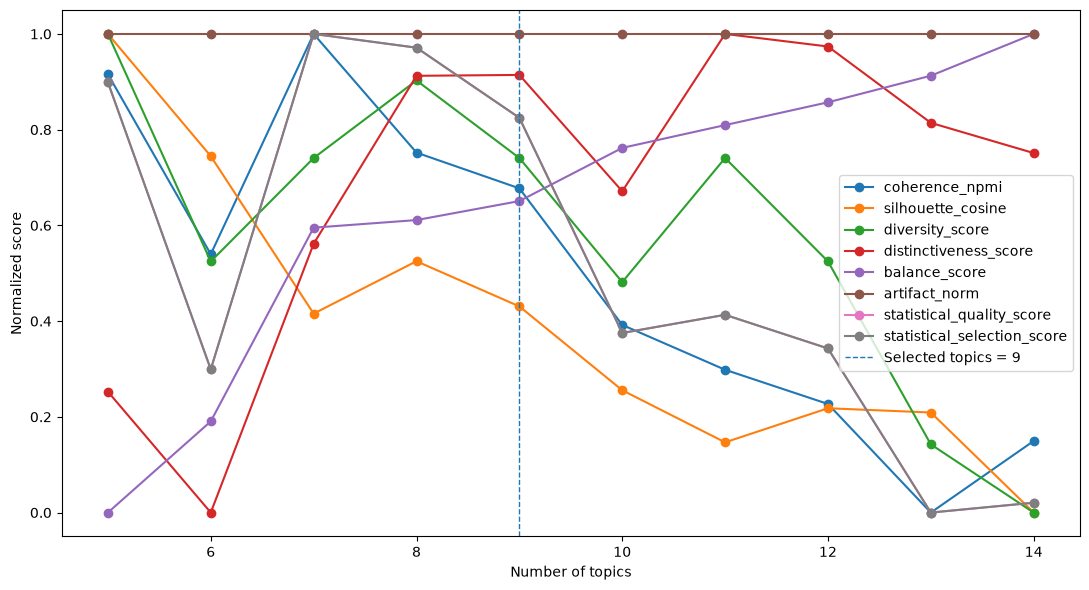

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/img/sentiment_nmf_topic_selection_metrics.png


In [12]:
# ==========================================
# Step 12: Plot topic-number selection metrics
# ==========================================

plot_topic_selection_metrics(
    topic_number_search_df,
    IMG_DIR / "sentiment_nmf_topic_selection_metrics.png",
)


In [13]:
# ==========================================
# Step 12: Fit final NMF topic model
# Main discovery on original sentiment documents only
# ==========================================

N_TOPICS = int(globals().get("SELECTED_N_TOPICS", 9))
TOP_N_WORDS = 12


# ------------------------------------------
# Reset old model outputs to avoid stale state
# ------------------------------------------

for variable_name in [
    "nmf_model",
    "document_topic_membership",
    "document_topic_membership_normalized",
    "topics",
    "topic_info",
    "topic_distribution",
    "topic_keywords_df",
]:
    if variable_name in globals():
        del globals()[variable_name]


# ------------------------------------------
# Fit NMF
# ------------------------------------------

nmf_model = NMF(
    n_components=N_TOPICS,
    init="nndsvda",
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver="cd",
    beta_loss="frobenius",
)

document_topic_membership = nmf_model.fit_transform(tfidf_matrix)
document_topic_membership_normalized = normalize(document_topic_membership, norm="l1")

topics = document_topic_membership.argmax(axis=1)
topic_confidence = document_topic_membership_normalized.max(axis=1)

sorted_membership = np.sort(document_topic_membership_normalized, axis=1)
topic_margin = sorted_membership[:, -1] - sorted_membership[:, -2]

nmf_df["topic"] = topics
nmf_df["topic_confidence"] = topic_confidence
nmf_df["topic_margin"] = topic_margin


# ------------------------------------------
# Topic distribution and keywords
# ------------------------------------------

topic_terms = topic_terms_from_components(
    nmf_model.components_,
    top_n=TOP_N_WORDS,
)

topic_distribution = (
    nmf_df["topic"]
    .value_counts()
    .sort_index()
    .rename_axis("topic")
    .reset_index(name="documents")
)

topic_distribution["share"] = (
    topic_distribution["documents"] / topic_distribution["documents"].sum()
).round(3)

topic_keywords_df = pd.DataFrame({
    "topic": list(range(N_TOPICS)),
    "keywords": [", ".join(terms) for terms in topic_terms],
})

topic_info = topic_distribution.merge(
    topic_keywords_df,
    on="topic",
    how="left",
)

topic_info["Name"] = topic_info.apply(
    lambda row: f"{int(row['topic'])}_" + "_".join(
        str(row["keywords"]).split(", ")[:4]
    ),
    axis=1,
)


# ------------------------------------------
# Topic keyword audit
# ------------------------------------------

topic_keyword_tokens = set(
    token
    for keywords in topic_keywords_df["keywords"].fillna("").astype(str)
    for token in keywords.replace(",", " ").split()
)

forbidden_found = sorted(set(bad_tokens) & topic_keyword_tokens)

if forbidden_found:
    raise ValueError(
        f"Forbidden terms still found in NMF topic labels: {forbidden_found}"
    )


# ------------------------------------------
# Save outputs
# ------------------------------------------

topic_info.to_csv(
    OUT_DIR / "sentiment_nmf_topic_info.csv",
    index=False,
    encoding="utf-8-sig",
)

topic_distribution.to_csv(
    OUT_DIR / "sentiment_nmf_topic_distribution.csv",
    index=False,
    encoding="utf-8-sig",
)

topic_keywords_df.to_csv(
    OUT_DIR / "sentiment_nmf_topic_keywords.csv",
    index=False,
    encoding="utf-8-sig",
)

nmf_df.to_csv(
    OUT_DIR / "sentiment_nmf_original_documents_with_topics.csv",
    index=False,
    encoding="utf-8-sig",
)

print("NMF topic model fitted")
print("=" * 80)
print(f"Documents used for fitting: {len(nmf_docs)}")
print(f"Selected/requested number of topics: {N_TOPICS}")
print(f"Discovered topics: {nmf_df['topic'].nunique()}")
print("Topic keyword audit passed.")

print("\nTopic information:")
print(topic_info)

print("\nTopic distribution:")
print(topic_distribution)

print("\nTopic keywords:")
print(topic_keywords_df)


NMF topic model fitted
Documents used for fitting: 455
Selected/requested number of topics: 9
Discovered topics: 9
Topic keyword audit passed.

Topic information:
   topic  documents  share  \
0      0         37  0.081   
1      1         72  0.158   
2      2         33  0.073   
3      3         90  0.198   
4      4         55  0.121   
5      5         67  0.147   
6      6         39  0.086   
7      7         33  0.073   
8      8         29  0.064   

                                                                                                                                                      keywords  \
0                                                     young, young people, people, child, social, impact, health, support, medium, mental, mental health, game   
1                                            student, teacher, teach, class, student student, help, increase, teacher student, grade, need, potential, mention   
2                                 learner, staff, 

In [14]:
# ==========================================
# Step 13: Inspect NMF topics and representative documents
# Main quality check before robustness testing
# ==========================================

TOP_N_REPRESENTATIVE_DOCS = 5


# ------------------------------------------
# Helper functions
# ------------------------------------------

def get_topic_keywords(topic_id, top_n=12):
    if topic_id < 0 or topic_id >= len(topic_terms):
        return ""

    return ", ".join(topic_terms[topic_id][:top_n])


def get_representative_docs_for_topic(topic_id, top_n=5):
    topic_indices = np.where(nmf_df["topic"].values == topic_id)[0]

    if len(topic_indices) == 0:
        return pd.DataFrame()

    scores = document_topic_membership_normalized[topic_indices, topic_id]
    ranked_local_indices = np.argsort(scores)[::-1][:top_n]
    ranked_global_indices = topic_indices[ranked_local_indices]

    result = nmf_df.iloc[ranked_global_indices].copy()
    result["representativeness_score"] = scores[ranked_local_indices]

    selected_columns = [
        "topic",
        "representativeness_score",
        "topic_confidence",
        "topic_margin",
        "doc_id",
        "source_type",
        "synthetic_type",
        "nmf_token_count",
        "nmf_source_text",
        "nmf_clean_text",
    ]

    existing_columns = [
        col for col in selected_columns
        if col in result.columns
    ]

    return result[existing_columns]


# ------------------------------------------
# Topic quality overview
# ------------------------------------------

topic_quality_rows = []
representative_rows = []

for topic_id in sorted(nmf_df["topic"].unique()):
    topic_subset = nmf_df[nmf_df["topic"] == topic_id]
    representative_docs = get_representative_docs_for_topic(
        topic_id,
        top_n=TOP_N_REPRESENTATIVE_DOCS,
    )

    topic_quality_rows.append({
        "topic": topic_id,
        "documents": len(topic_subset),
        "share": round(len(topic_subset) / len(nmf_df), 3),
        "mean_confidence": round(float(topic_subset["topic_confidence"].mean()), 4),
        "mean_margin": round(float(topic_subset["topic_margin"].mean()), 4),
        "keywords": get_topic_keywords(topic_id),
    })

    representative_rows.extend(representative_docs.to_dict("records"))

topic_quality_df = pd.DataFrame(topic_quality_rows)
representative_docs_df = pd.DataFrame(representative_rows)

representative_docs_df.to_csv(
    OUT_DIR / "sentiment_nmf_representative_documents.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Topic quality overview")
print("=" * 80)
print(topic_quality_df)

for topic_id in sorted(nmf_df["topic"].unique()):
    print("\n" + "=" * 100)
    print(f"Topic {topic_id}")
    print("=" * 100)
    print("Keywords:")
    print(get_topic_keywords(topic_id))
    print("\nRepresentative documents:")

    print(
        get_representative_docs_for_topic(
            topic_id,
            top_n=TOP_N_REPRESENTATIVE_DOCS,
        )
    )


Topic quality overview
   topic  documents  share  mean_confidence  mean_margin  \
0      0         37  0.081           0.6515       0.4327   
1      1         72  0.158           0.6915       0.4859   
2      2         33  0.073           0.7337       0.5702   
3      3         90  0.198           0.6562       0.4508   
4      4         55  0.121           0.7283       0.5436   
5      5         67  0.147           0.6566       0.4535   
6      6         39  0.086           0.7132       0.5692   
7      7         33  0.073           0.6903       0.4711   
8      8         29  0.064           0.8353       0.7406   

                                                                                                                                                      keywords  
0                                                     young, young people, people, child, social, impact, health, support, medium, mental, mental health, game  
1                                            student, 

In [15]:
# ==========================================
# Step 14: Generate topic-level SLM labels and prototypes
# One SLM call per topic only
# ==========================================

if not SLM_AVAILABLE:
    raise RuntimeError(
        "SLM is not available. Stop here instead of silently using fallback labels. "
        "Check Cell 8 model loading, HF_TOKEN, torch, device memory, and transformers version."
    )

def fallback_topic_label(keywords):
    terms = [term.strip() for term in str(keywords).split(",") if term.strip()]
    return " / ".join(terms[:4]) if terms else "Unlabelled topic"


topic_labels_rows = []

for _, row in topic_info.iterrows():
    topic_id = int(row["topic"])
    keywords = str(row["keywords"])

    topic_representatives = representative_docs_df[
        representative_docs_df["topic"].eq(topic_id)
    ].copy()

    score_cols = [
        col for col in [
            "topic_weight",
            "topic_score",
            "nmf_weight",
            "probability",
            "score",
        ]
        if col in topic_representatives.columns
    ]

    if score_cols:
        topic_representatives = topic_representatives.sort_values(
            score_cols[0],
            ascending=False,
        )

    topic_representatives = topic_representatives.head(4)

    representative_snippets = []

    for _, doc_row in topic_representatives.iterrows():
        snippet = str(doc_row.get("nmf_source_text", ""))
        snippet = re.sub(r"\s+", " ", snippet).strip()
        representative_snippets.append(snippet[:700])

    slm_raw = ""
    slm_json = {}

    if SLM_AVAILABLE:
        label_prompt = f"""
You are labelling one topic from a sentiment/public-opinion corpus about AI, education, youth, ethics, and society.

Your task is to produce a specific, human-readable topic label.

Top keywords:
{keywords}

Representative documents:
{chr(10).join('- ' + snippet for snippet in representative_snippets[:3])}

Return exactly one valid JSON object with this schema:
{{
  "label": "specific topic label, 5 to 12 words",
  "prototype": "one clear sentence describing the topic",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}}

Label rules:
- Do NOT use generic labels such as "AI in Education", "AI in Society", "Ethics in AI", or "Digital Technology".
- The label must mention the concrete theme, actor, or setting.
- Prefer labels like:
  "Classroom AI Tools and Student Learning Practices"
  "Teacher Professional Development Around Generative AI"
  "Youth Workers Responding to AI Governance Challenges"
  "Public Fear and Optimism About AI Employment Impact"
- Avoid vague words such as "unclear", "miscellaneous", "general", or "topic".
- If the topic is about education, say what part of education: classroom tools, assessment, teacher training, student learning, professional development.
- If the topic is about society, say what social issue: employment, fear, optimism, public perception, digitalization.
- Use double quotes.
- Use true or false, not True or False.
- Do not include Markdown.
- Do not include explanations outside JSON.
""".strip()

        slm_raw = slm_generate(label_prompt, max_new_tokens=LABEL_SLM_MAX_NEW_TOKENS)
        slm_json = extract_json_object(slm_raw)

        print(f"\nTopic {topic_id} SLM raw response:")
        print(slm_raw[:500])

        if not slm_json:
            raise RuntimeError(
                f"Could not parse SLM JSON for topic {topic_id}. Raw response:\n{slm_raw}"
            )

    label = str(slm_json.get("label", "")).strip()
    prototype = str(slm_json.get("prototype", "")).strip()

    if not label:
        label = fallback_topic_label(keywords)

    if not prototype:
        prototype = f"Topic about {fallback_topic_label(keywords)}."

    topic_labels_rows.append({
        "topic": topic_id,
        "topic_label": label,
        "topic_prototype": prototype,
        "is_coherent": slm_json.get("is_coherent", ""),
        "artifact_topic": slm_json.get("artifact_topic", ""),
        "merge_hint": str(slm_json.get("merge_hint", "")).strip(),
        "keywords": keywords,
        "slm_raw_response": slm_raw,
    })


topic_labels_df = pd.DataFrame(topic_labels_rows)

topic_labels_df.to_csv(
    OUT_DIR / "sentiment_nmf_topic_labels_final.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Topic-level SLM refinement complete")
print("=" * 80)
print("SLM available:", SLM_AVAILABLE)
print(topic_labels_df[[
    "topic",
    "topic_label",
    "topic_prototype",
    "is_coherent",
    "artifact_topic",
    "merge_hint",
]])



Topic 0 SLM raw response:
```json
{
  "label": "Young People's AI Impact on Education and Well-being",
  "prototype": "The article discusses the influence of AI on young people's education and overall well-being.",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": ""
}
```

Topic 1 SLM raw response:
```json
{
  "label": "Student Engagement and Teacher Adaptation to AI in Classrooms",
  "prototype": "This study explores how students' engagement with AI tools impacts teacher adaptation strategies.",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with 'Teacher Training Programs on AI Integration'"
}
```

Topic 2 SLM raw response:
```json
{
  "label": "GenAI Detection and Assessment Confusion Among Learners and Staff",
  "prototype": "A study examining confusion among learners and staff regarding the use of GenAI in assessment and its reliability.",
  "is_coherent": true,
  "artifact_topic": false,
  "merge_hint": "Merge with studies focusing on G

In [16]:
# ==========================================
# Step 15: Synthetic robustness report
# Synthetic data is used only for validation
# ==========================================

if synthetic_tfidf_matrix is None or len(synthetic_nmf_df) == 0:
    synthetic_robustness_df = pd.DataFrame()
    low_confidence_synthetic_df = pd.DataFrame()
    print("No synthetic documents available for robustness checks.")
else:
    # ------------------------------------------
    # Assign synthetic documents to existing NMF topics
    # ------------------------------------------

    synthetic_membership = nmf_model.transform(synthetic_tfidf_matrix)
    synthetic_membership_normalized = normalize(synthetic_membership, norm="l1")

    synthetic_topics = synthetic_membership.argmax(axis=1)
    synthetic_confidence = synthetic_membership_normalized.max(axis=1)

    synthetic_sorted_membership = np.sort(synthetic_membership_normalized, axis=1)
    synthetic_margin = synthetic_sorted_membership[:, -1] - synthetic_sorted_membership[:, -2]

    synthetic_nmf_df = synthetic_nmf_df.copy()
    synthetic_nmf_df["assigned_topic"] = synthetic_topics
    synthetic_nmf_df["topic_confidence"] = synthetic_confidence
    synthetic_nmf_df["topic_margin"] = synthetic_margin


    # ------------------------------------------
    # Compare original and synthetic topic distributions
    # ------------------------------------------

    original_topic_distribution = (
        nmf_df["topic"]
        .value_counts()
        .sort_index()
        .rename_axis("topic")
        .reset_index(name="original_documents")
    )

    synthetic_topic_distribution = (
        synthetic_nmf_df["assigned_topic"]
        .value_counts()
        .sort_index()
        .rename_axis("topic")
        .reset_index(name="synthetic_documents")
    )

    synthetic_robustness_df = original_topic_distribution.merge(
        synthetic_topic_distribution,
        on="topic",
        how="outer",
    ).fillna(0)

    synthetic_robustness_df["original_share"] = (
        synthetic_robustness_df["original_documents"]
        / synthetic_robustness_df["original_documents"].sum()
    ).round(3)

    synthetic_robustness_df["synthetic_share"] = (
        synthetic_robustness_df["synthetic_documents"]
        / synthetic_robustness_df["synthetic_documents"].sum()
    ).round(3)

    synthetic_robustness_df["share_difference"] = (
        synthetic_robustness_df["synthetic_share"]
        - synthetic_robustness_df["original_share"]
    ).round(3)

    synthetic_robustness_df = synthetic_robustness_df.merge(
        topic_keywords_df,
        on="topic",
        how="left",
    )

    if "topic_labels_df" in globals():
        synthetic_robustness_df = synthetic_robustness_df.merge(
            topic_labels_df[["topic", "topic_label", "topic_prototype"]],
            on="topic",
            how="left",
        )


    # ------------------------------------------
    # Low-confidence synthetic assignments
    # ------------------------------------------

    LOW_CONFIDENCE_THRESHOLD = synthetic_nmf_df["topic_margin"].quantile(0.10)

    low_confidence_synthetic_df = synthetic_nmf_df[
        synthetic_nmf_df["topic_margin"] <= LOW_CONFIDENCE_THRESHOLD
    ].copy()


    # ------------------------------------------
    # Save outputs
    # ------------------------------------------

    synthetic_nmf_df.to_csv(
        OUT_DIR / "sentiment_nmf_synthetic_assignments.csv",
        index=False,
        encoding="utf-8-sig",
    )

    synthetic_robustness_df.to_csv(
        OUT_DIR / "sentiment_nmf_synthetic_robustness_report.csv",
        index=False,
        encoding="utf-8-sig",
    )


    # ------------------------------------------
    # Display concise report
    # ------------------------------------------

    print("Synthetic robustness report")
    print("=" * 80)
    print("Synthetic documents were assigned to existing original-data NMF topics.")
    print("They were not used to fit the final topic model.")

    print("\nOriginal vs synthetic topic distribution:")
    print(
        synthetic_robustness_df[[
            "topic",
            "original_documents",
            "synthetic_documents",
            "original_share",
            "synthetic_share",
            "share_difference",
            "keywords",
        ]]
    )

    print("\nSynthetic confidence summary:")
    print(
        synthetic_nmf_df[["topic_confidence", "topic_margin"]]
        .describe()
    )

    print(f"\nLow-confidence synthetic examples: {len(low_confidence_synthetic_df)}")
    print(
        low_confidence_synthetic_df[[
            "assigned_topic",
            "topic_confidence",
            "topic_margin",
            "doc_id",
            "source_type",
            "synthetic_type",
            "nmf_clean_text",
        ]].head(20)
    )


Synthetic robustness report
Synthetic documents were assigned to existing original-data NMF topics.
They were not used to fit the final topic model.

Original vs synthetic topic distribution:
   topic  original_documents  synthetic_documents  original_share  synthetic_share  share_difference  \
0      0                  37                 16.0           0.081            0.079            -0.002   
1      1                  72                 21.0           0.158            0.104            -0.054   
2      2                  33                  1.0           0.073            0.005            -0.068   
3      3                  90                 57.0           0.198            0.282             0.084   
4      4                  55                 24.0           0.121            0.119            -0.002   
5      5                  67                 19.0           0.147            0.094            -0.053   
6      6                  39                 46.0           0.086            0.2

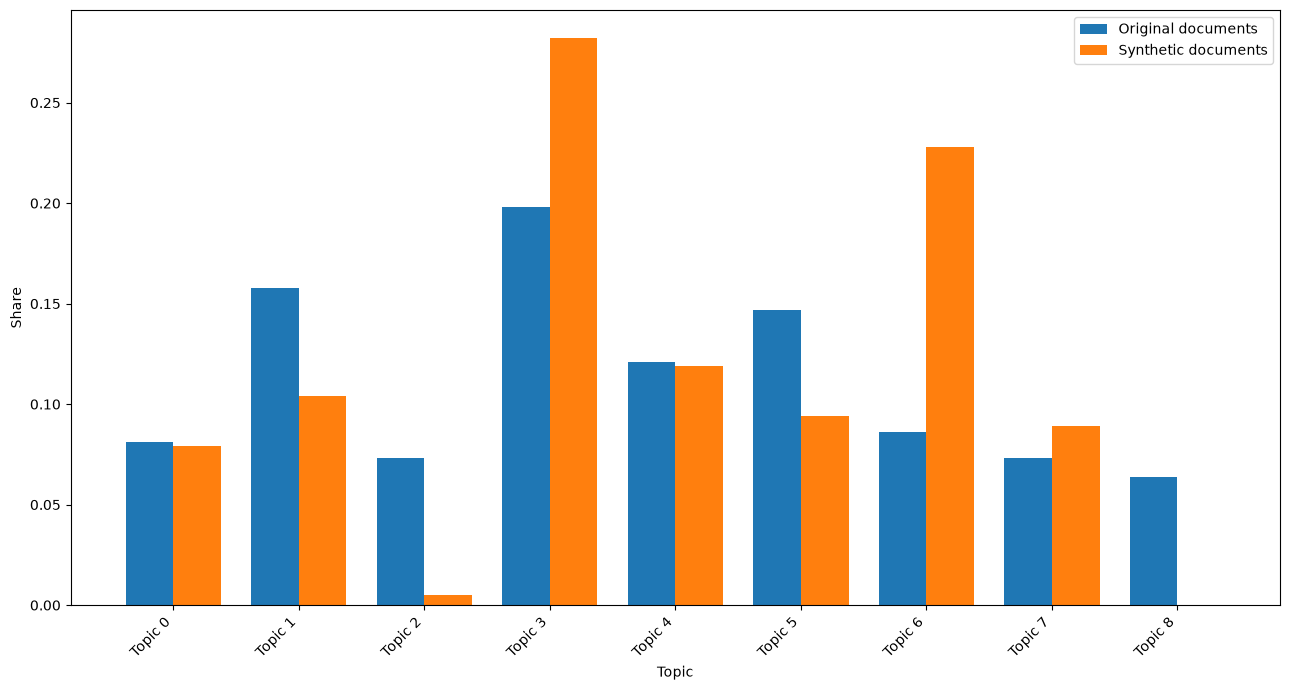

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/img/sentiment_nmf_original_vs_synthetic_distribution.png


In [17]:
# ==========================================
# Step 17: Plot original vs synthetic topic distribution
# ==========================================

if "synthetic_robustness_df" not in globals() or len(synthetic_robustness_df) == 0:
    print("synthetic_robustness_df not found or empty. Run the synthetic robustness cell first.")

else:
    plot_original_vs_synthetic_distribution(
        synthetic_robustness_df,
        IMG_DIR / "sentiment_nmf_original_vs_synthetic_distribution.png",
        topic_keyword_df=topic_keywords_df if "topic_keywords_df" in globals() else None,
        topic_phrase_df=topic_labels_df if "topic_labels_df" in globals() else None,
    )


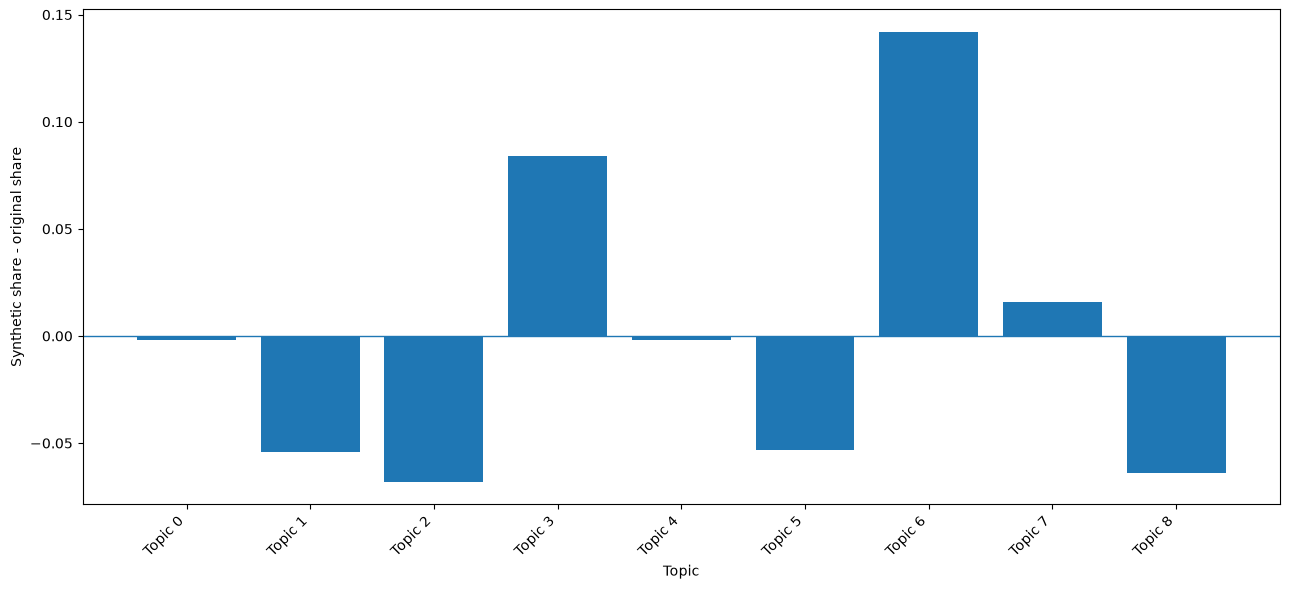

Saved: /home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/img/sentiment_nmf_synthetic_share_difference.png


In [18]:
# ==========================================
# Step 18: Plot synthetic-original share difference
# ==========================================

if "synthetic_robustness_df" not in globals() or len(synthetic_robustness_df) == 0:
    print("synthetic_robustness_df not found or empty. Run the synthetic robustness cell first.")

else:
    plot_synthetic_share_difference(
        synthetic_robustness_df,
        IMG_DIR / "sentiment_nmf_synthetic_share_difference.png",
        topic_keyword_df=topic_keywords_df if "topic_keywords_df" in globals() else None,
        topic_phrase_df=topic_labels_df if "topic_labels_df" in globals() else None,
    )


In [19]:
# ==========================================
# Step 18: Apply final automatic SLM labels
# No manual topic labels are defined in this pipeline
# ==========================================

if "topic_labels_df" in globals():
    topic_label_map = dict(
        zip(topic_labels_df["topic"], topic_labels_df["topic_label"])
    )

    topic_prototype_map = dict(
        zip(topic_labels_df["topic"], topic_labels_df["topic_prototype"])
    )

    nmf_df["topic_label"] = nmf_df["topic"].map(topic_label_map)
    nmf_df["topic_prototype"] = nmf_df["topic"].map(topic_prototype_map)

    if "synthetic_nmf_df" in globals() and "assigned_topic" in synthetic_nmf_df.columns:
        synthetic_nmf_df["topic_label"] = synthetic_nmf_df["assigned_topic"].map(topic_label_map)
        synthetic_nmf_df["topic_prototype"] = synthetic_nmf_df["assigned_topic"].map(topic_prototype_map)

    topic_info = topic_info.merge(
        topic_labels_df[["topic", "topic_label", "topic_prototype"]],
        on="topic",
        how="left",
    )

    print("Applied automatic SLM topic labels.")
    print(topic_info)
else:
    print("topic_labels_df not found; no labels were applied.")


Applied automatic SLM topic labels.
   topic  documents  share  \
0      0         37  0.081   
1      1         72  0.158   
2      2         33  0.073   
3      3         90  0.198   
4      4         55  0.121   
5      5         67  0.147   
6      6         39  0.086   
7      7         33  0.073   
8      8         29  0.064   

                                                                                                                                                      keywords  \
0                                                     young, young people, people, child, social, impact, health, support, medium, mental, mental health, game   
1                                            student, teacher, teach, class, student student, help, increase, teacher student, grade, need, potential, mention   
2                                 learner, staff, extremely, assessment, unsure, likely, course, staff learner, provider, academic, guidance, extremely likely   
3              

In [20]:
# ==========================================
# Step 19: Final CSV exports
# Keep only dissertation-relevant outputs
# ==========================================

if "synthetic_robustness_df" not in globals():
    synthetic_robustness_df = pd.DataFrame()

if "synthetic_nmf_df" not in globals():
    synthetic_nmf_df = pd.DataFrame()

final_csv_exports = {
    "sentiment_nmf_topic_number_search.csv": topic_number_search_df,
    "sentiment_nmf_topic_selection_summary.csv": selection_summary_df,
    "sentiment_nmf_topic_info.csv": topic_info,
    "sentiment_nmf_topic_distribution.csv": topic_distribution,
    "sentiment_nmf_topic_keywords.csv": topic_keywords_df,
    "sentiment_nmf_representative_documents.csv": representative_docs_df,
    "sentiment_nmf_topic_labels_final.csv": topic_labels_df,
    "sentiment_nmf_original_documents_with_topic_labels_final.csv": nmf_df,
    "sentiment_nmf_synthetic_assignments_with_topic_labels_final.csv": synthetic_nmf_df,
    "sentiment_nmf_synthetic_robustness_report.csv": synthetic_robustness_df,
}

for filename, dataframe in final_csv_exports.items():
    dataframe.to_csv(
        OUT_DIR / filename,
        index=False,
        encoding="utf-8-sig",
    )

print("Final NMF + SLM topic pipeline exports complete")
print("=" * 80)
for filename in final_csv_exports:
    print(OUT_DIR / filename)


Final NMF + SLM topic pipeline exports complete
/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_topic_number_search.csv
/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_topic_selection_summary.csv
/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_topic_info.csv
/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_topic_distribution.csv
/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_topic_keywords.csv
/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_representative_documents.csv
/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_topic_labels_final.csv
/home/nsirim/Github/mscdsa/msc/progress/topic_modelling/nmf/sentiment/output/sentiment_nmf_original_documents_with_topic_labels_final.csv
/home/nsirim/Git